In [1]:
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.layers import Dense,Conv2D,Flatten,Dropout,Activation,MaxPooling2D,Add,ZeroPadding2D,UpSampling2D,GlobalAveragePooling2D,GlobalMaxPooling2D
from tensorflow.keras.models import Sequential,Model
from keras.utils import  np_utils
from tensorflow.keras.layers import Input,BatchNormalization
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.datasets import cifar100
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os
from skimage.io import imread
from skimage.transform import resize
import albumentations as albu
from tensorflow.keras.applications.efficientnet import EfficientNetB0
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit


In [2]:
(x_train,y_train),(x_test,y_test) = cifar100.load_data()
X_val,y_val = x_train[40000:,:],y_train[40000:]
X_train,y_train = x_train[:40000,:],y_train[:40000]

169009152/169001437 [==============================] - 4s 0us/step


In [3]:
n_classes = 100
epochs = 25
batch_size = 32

In [4]:
X_train = keras.applications.efficientnet.preprocess_input(X_train)
X_val = keras.applications.efficientnet.preprocess_input(X_val)
X_test = keras.applications.efficientnet.preprocess_input(x_test)

In [5]:
Y_train = np_utils.to_categorical(y_train,n_classes)
Y_val = np_utils.to_categorical(y_val,n_classes)
Y_test = np_utils.to_categorical(y_test,n_classes)

In [34]:
#eff_model = EfficientNetB0(weights='imagenet',include_top=False,input_tensor=Input(shape=(256,256,3)))
eff_model = EfficientNetB0(weights='imagenet',input_shape=(256,256,3),include_top=False)
eff_model.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
rescaling_5 (Rescaling)         (None, 256, 256, 3)  0           input_6[0][0]                    
__________________________________________________________________________________________________
normalization_5 (Normalization) (None, 256, 256, 3)  7           rescaling_5[0][0]                
__________________________________________________________________________________________________
stem_conv_pad (ZeroPadding2D)   (None, 257, 257, 3)  0           normalization_5[0][0]            
_____________________________________________________________________________________

In [35]:
model = Sequential([
                    UpSampling2D(),
                    UpSampling2D(),
                    UpSampling2D(),
                    eff_model,
                    GlobalAveragePooling2D(),
                    Dense(1024, activation='relu'),
                    BatchNormalization(),
                    Dense(512,activation='relu'),
                    BatchNormalization(),
                    Dense(218,activation='relu'),
                    BatchNormalization(),
                    Dense(n_classes,activation='softmax')
])
model.build(input_shape=(32,32,32,3))
model.summary()

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
up_sampling2d_30 (UpSampling (32, 64, 64, 3)           0         
_________________________________________________________________
up_sampling2d_31 (UpSampling (32, 128, 128, 3)         0         
_________________________________________________________________
up_sampling2d_32 (UpSampling (32, 256, 256, 3)         0         
_________________________________________________________________
efficientnetb0 (Functional)  (None, 8, 8, 1280)        4049571   
_________________________________________________________________
global_average_pooling2d_10  (32, 1280)                0         
_________________________________________________________________
dense_40 (Dense)             (32, 1024)                1311744   
_________________________________________________________________
batch_normalization_30 (Batc (32, 1024)              

In [36]:
opt = keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="categorical_crossentropy",optimizer=opt,metrics=['accuracy'])

In [37]:
!ln -s /content/drive/MyDrive/ML


ln: failed to create symbolic link './ML': File exists


In [38]:

name_model = "Best_weight.h5"
filepath = os.path.join(name_model)

In [39]:
checkpoint = keras.callbacks.ModelCheckpoint(filepath=filepath, monitor='val_accuracy',verbose=1,save_best_only=True)
re = keras.callbacks.ReduceLROnPlateau(monitor='val_loss',mode='min',patience=5,min_lr = 1e-6,factor=0.5)

In [40]:
aug_train = ImageDataGenerator(rescale=1./255,zoom_range=0.2,rotation_range=30,horizontal_flip=True,vertical_flip=True,
                               fill_mode='nearest',height_shift_range=0.2,width_shift_range=0.2)
aug_test = ImageDataGenerator(rescale=1./255)


In [41]:
H = model.fit(X_train,Y_train, validation_data = (X_val,Y_val),verbose = 1, callbacks=[checkpoint,re],epochs=epochs,batch_size = batch_size)

Epoch 1/25
1250/1250 [==============================] - 544s 405ms/step - loss: 4.5345 - accuracy: 0.0618 - val_loss: 3.7799 - val_accuracy: 0.1629

Epoch 00001: val_accuracy improved from -inf to 0.16290, saving model to Best_weight.h5


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


Epoch 2/25
1250/1250 [==============================] - 504s 403ms/step - loss: 3.3111 - accuracy: 0.2433 - val_loss: 2.8542 - val_accuracy: 0.3310

Epoch 00002: val_accuracy improved from 0.16290 to 0.33100, saving model to Best_weight.h5
Epoch 3/25
1250/1250 [==============================] - 505s 404ms/step - loss: 2.5600 - accuracy: 0.3939 - val_loss: 2.1755 - val_accuracy: 0.4665

Epoch 00003: val_accuracy improved from 0.33100 to 0.46650, saving model to Best_weight.h5
Epoch 4/25
1250/1250 [==============================] - 505s 404ms/step - loss: 2.1071 - accuracy: 0.4891 - val_loss: 1.8088 - val_accuracy: 0.5450

Epoch 00004: val_accuracy improved from 0.46650 to 0.54500, saving model to Best_weight.h5
Epoch 5/25
1250/1250 [==============================] - 504s 403ms/step - loss: 1.8099 - accuracy: 0.5534 - val_loss: 1.5729 - val_accuracy: 0.5933

Epoch 00005: val_accuracy improved from 0.54500 to 0.59330, saving model to Best_weight.h5
Epoch 6/25
1250/1250 [==================

In [42]:
score = model.evaluate(X_test,Y_test)
print("loss : ",score[0])
print("accuracy : ",score[1])

313/313 [==============================] - 43s 137ms/step - loss: 0.7432 - accuracy: 0.7849
loss :  0.7431501150131226
accuracy :  0.7849000096321106


In [48]:
from tensorflow.keras.models import load_model
model1  = load_model("Best_weight.h5")
score = model1.evaluate(X_test,Y_test)
print("loss : ",score[0])
print("accuracy : ",score[1])

313/313 [==============================] - 44s 136ms/step - loss: 0.7432 - accuracy: 0.7849
loss :  0.7431501150131226
accuracy :  0.7849000096321106


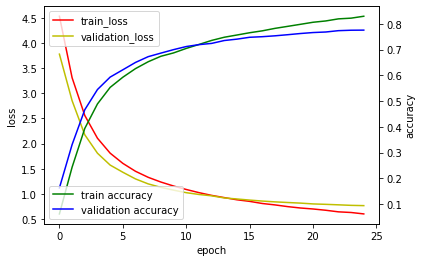

In [49]:
fig ,loss_ax = plt.subplots()
acc_ax = loss_ax.twinx()

loss_ax.plot(H.history['loss'],'r',label = 'train_loss')
loss_ax.plot(H.history['val_loss'],'y',label = 'validation_loss')

acc_ax.plot(H.history['accuracy'],'g',label = "train accuracy")
acc_ax.plot(H.history['val_accuracy'],'b',label = "validation accuracy")

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')

loss_ax.legend(loc = 'upper left')
acc_ax.legend(loc = 'lower left')
plt.show()